EDA - wczytanie danych i analiza

In [90]:
import pandas as pd
import numpy as np

df = pd.read_json('fast_cars_data.json')

df.info()
df.describe()
df.head()

<class 'pandas.DataFrame'>
RangeIndex: 15968 entries, 0 to 15967
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   Tytuł              15968 non-null  str  
 1   Cena               15968 non-null  str  
 2   URL                15968 non-null  str  
 3   Rok produkcji      15968 non-null  int64
 4   Przebieg           15968 non-null  str  
 5   Pojemność skokowa  15968 non-null  str  
 6   Moc                15968 non-null  str  
 7   Rodzaj paliwa      15968 non-null  str  
 8   Skrzynia biegów    15968 non-null  str  
dtypes: int64(1), str(8)
memory usage: 1.1 MB


,Tytuł,Cena,URL,Rok produkcji,Przebieg,Pojemność skokowa,Moc,Rodzaj paliwa,Skrzynia biegów
0,Mercedes-Benz EQE 350 89kWh 4-Matic Electric Art,327809 PLN,https://www.otomoto.pl/osobowe/oferta/mercedes...,2025,1 km,Brak,292 KM,Elektryczny,Automatyczna
1,Volvo S90 T5 Geartronic Inscription,59000 PLN,https://www.otomoto.pl/osobowe/oferta/volvo-s9...,2020,118760 km,1969 cm3,254 KM,Benzyna,Automatyczna
2,BMW Seria 5 530i M Sport Edition,80000 PLN,https://www.otomoto.pl/osobowe/oferta/bmw-seri...,2019,120000 km,1998 cm3,252 KM,Benzyna,Automatyczna
3,Tesla Model S Plaid,239000 PLN,https://www.otomoto.pl/osobowe/oferta/tesla-mo...,2022,22 km,Brak,1020 KM,Elektryczny,Automatyczna
4,BAIC 3,74900 PLN,https://www.otomoto.pl/osobowe/oferta/baic-3-I...,2026,5 km,1499 cm3,136 KM,Benzyna,Manualna


In [91]:
df = df.replace('Brak', np.nan)

braki = df[['Rok produkcji', 'Cena', 'Przebieg', 'Pojemność skokowa', 'Moc', 'Rodzaj paliwa', 'Skrzynia biegów']].isna().sum()
print(braki)

def test(df):
    warunek_brak_pojemnosci = df['Pojemność skokowa'].isna()
    warunek_elektryk = df['Rodzaj paliwa'] == 'Elektryczny'
    warunek_moc = df['Moc'].isna()

    unikalne_paliwa = df['Rodzaj paliwa'].unique()

    print("Dostępne rodzaje paliwa w bazie:")
    print(unikalne_paliwa)

    for typ_paliwa in unikalne_paliwa:
        warunek_paliwo = df['Rodzaj paliwa'] == typ_paliwa
        print(f"Liczba aut o paliwie \"{typ_paliwa}\": {warunek_paliwo.sum()}")
        print(f"Ilość wpisów z brakującą pojemnością skokową dla tego paliwa \"{typ_paliwa}\": {(warunek_paliwo & warunek_brak_pojemnosci).sum()}")
        print(f"Ilość wpisów z brakującą mocą dla tego paliwa \"{typ_paliwa}\": {(warunek_paliwo & warunek_moc).sum()}")
        
test(df)
df = df.drop_duplicates()
test(df)


Rok produkcji          0
Cena                   0
Przebieg               0
Pojemność skokowa    312
Moc                  126
Rodzaj paliwa          0
Skrzynia biegów        1
dtype: int64
Dostępne rodzaje paliwa w bazie:
<StringArray>
[    'Elektryczny',         'Benzyna', 'Hybryda Plug-in',          'Diesel',
         'Hybryda',     'Benzyna+LPG',     'Benzyna+CNG',           'Wodór']
Length: 8, dtype: str
Liczba aut o paliwie "Elektryczny": 256
Ilość wpisów z brakującą pojemnością skokową dla tego paliwa "Elektryczny": 256
Ilość wpisów z brakującą mocą dla tego paliwa "Elektryczny": 2
Liczba aut o paliwie "Benzyna": 7944
Ilość wpisów z brakującą pojemnością skokową dla tego paliwa "Benzyna": 27
Ilość wpisów z brakującą mocą dla tego paliwa "Benzyna": 65
Liczba aut o paliwie "Hybryda Plug-in": 434
Ilość wpisów z brakującą pojemnością skokową dla tego paliwa "Hybryda Plug-in": 2
Ilość wpisów z brakującą mocą dla tego paliwa "Hybryda Plug-in": 3
Liczba aut o paliwie "Diesel": 5959
Ilość

Czyszczenie danych i zamiana tekstu na liczby

In [92]:
print(f"Rozmiar bazy na start: {len(df)}")

df = df[~df['Rodzaj paliwa'].isin(['Benzyna+CNG', 'Wodór'])]

df.loc[df['Rodzaj paliwa'] == 'Elektryczny', 'Pojemność skokowa'] = '0'

df = df.dropna(subset=['Moc', 'Pojemność skokowa', 'Skrzynia biegów'])

print(f"Rozmiar bazy po usunięciu braków i mikrogrup: {len(df)}")


df['Cena'] = df['Cena'].astype(str)
df = df[df['Cena'].str.contains('PLN', na=False)]
df['Cena'] = df['Cena'].str.replace(' PLN', '', regex=False)
df['Cena'] = df['Cena'].str.replace(' ', '', regex=False)
df['Cena'] = df['Cena'].astype(float).astype(int)

df['Przebieg'] = df['Przebieg'].astype(str).str.replace(' km', '', regex=False)
df['Przebieg'] = df['Przebieg'].str.replace(' ', '', regex=False)
df['Przebieg'] = df['Przebieg'].astype(int)

df['Moc'] = df['Moc'].astype(str).str.replace(' KM', '', regex=False)
df['Moc'] = df['Moc'].str.replace(' ', '', regex=False)
df['Moc'] = df['Moc'].astype(int)

df['Pojemność skokowa'] = df['Pojemność skokowa'].astype(str).str.replace(' cm3', '', regex=False)
df['Pojemność skokowa'] = df['Pojemność skokowa'].str.replace(' ', '', regex=False)
# Tu używamy float a potem int, żeby ładnie przekonwertować zera
df['Pojemność skokowa'] = df['Pojemność skokowa'].astype(float).astype(int) 

print("\nSukces! Twoje dane są teraz czystymi liczbami.")

Rozmiar bazy na start: 14525
Rozmiar bazy po usunięciu braków i mikrogrup: 14383

Sukces! Twoje dane są teraz czystymi liczbami.


In [93]:
df.info()
df.describe()

<class 'pandas.DataFrame'>
Index: 14355 entries, 0 to 15967
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   Tytuł              14355 non-null  str  
 1   Cena               14355 non-null  int64
 2   URL                14355 non-null  str  
 3   Rok produkcji      14355 non-null  int64
 4   Przebieg           14355 non-null  int64
 5   Pojemność skokowa  14355 non-null  int64
 6   Moc                14355 non-null  int64
 7   Rodzaj paliwa      14355 non-null  str  
 8   Skrzynia biegów    14355 non-null  str  
dtypes: int64(5), str(4)
memory usage: 1.1 MB


,Cena,Rok produkcji,Przebieg,Pojemność skokowa,Moc
count,1.435500e+04,14355.000000,1.435500e+04,14355.000000,14355.000000
mean,8.531161e+04,2016.365796,1.379234e+05,1873.070359,173.791432
std,1.166626e+05,7.288011,1.024787e+05,790.059720,94.033973
min,1.000000e+03,1956.000000,0.000000e+00,0.000000,1.000000
25%,2.450000e+04,2012.000000,5.158050e+04,1490.000000,116.000000
50%,4.999900e+04,2017.000000,1.378910e+05,1798.000000,150.000000
75%,1.079000e+05,2022.000000,2.034200e+05,1996.000000,197.000000
max,4.522000e+06,2026.000000,2.861515e+06,6749.000000,1401.000000


Sprawdzanie wartości odstających i usuwanie ich

In [94]:
Q1 = df['Cena'].quantile(0.25)
Q3 = df['Cena'].quantile(0.75)

IQR = Q3 - Q1

df_outliers = df[(df['Cena'] < Q1 - 1.5 * IQR) | (df['Cena'] > Q3 + 1.5 * IQR)]

df_outliers

,Tytuł,Cena,URL,Rok produkcji,Przebieg,Pojemność skokowa,Moc,Rodzaj paliwa,Skrzynia biegów
0,Mercedes-Benz EQE 350 89kWh 4-Matic Electric Art,327809,https://www.otomoto.pl/osobowe/oferta/mercedes...,2025,1,0,292,Elektryczny,Automatyczna
3,Tesla Model S Plaid,239000,https://www.otomoto.pl/osobowe/oferta/tesla-mo...,2022,22,0,1020,Elektryczny,Automatyczna
5,Mercedes-Benz Klasa C AMG 43 mHEV 4-Matic,389900,https://www.otomoto.pl/osobowe/oferta/mercedes...,2025,1,1991,408,Benzyna,Automatyczna
6,Mercedes-Benz Klasa A,317326,https://www.otomoto.pl/osobowe/oferta/mercedes...,2026,1,1991,421,Benzyna,Automatyczna
13,Mercedes-Benz GLC 220 d mHEV 4-Matic AMG Line,347878,https://www.otomoto.pl/osobowe/oferta/mercedes...,2026,1,1993,197,Diesel,Automatyczna
...,...,...,...,...,...,...,...,...,...
15852,Porsche 911 Turbo S,654911,https://www.otomoto.pl/osobowe/oferta/porsche-...,2016,96272,3800,581,Benzyna,Automatyczna
15853,BMW Seria 5 520d xDrive mHEV M Sport,299900,https://www.otomoto.pl/osobowe/oferta/bmw-seri...,2026,7,1995,197,Diesel,Automatyczna
15854,Porsche Cayenne,659900,https://www.otomoto.pl/osobowe/oferta/porsche-...,2022,35000,3996,680,Hybryda Plug-in,Automatyczna
15867,Land Rover Range Rover D350 SV,489000,https://www.otomoto.pl/osobowe/oferta/land-rov...,2023,140000,2997,350,Diesel,Automatyczna


To powyżej jest niepoprawnym sposobem w tym przypadku na identyfikowanie outlierów, bo nie jest to rozkład normalny, a z asymetrią prawostronną.

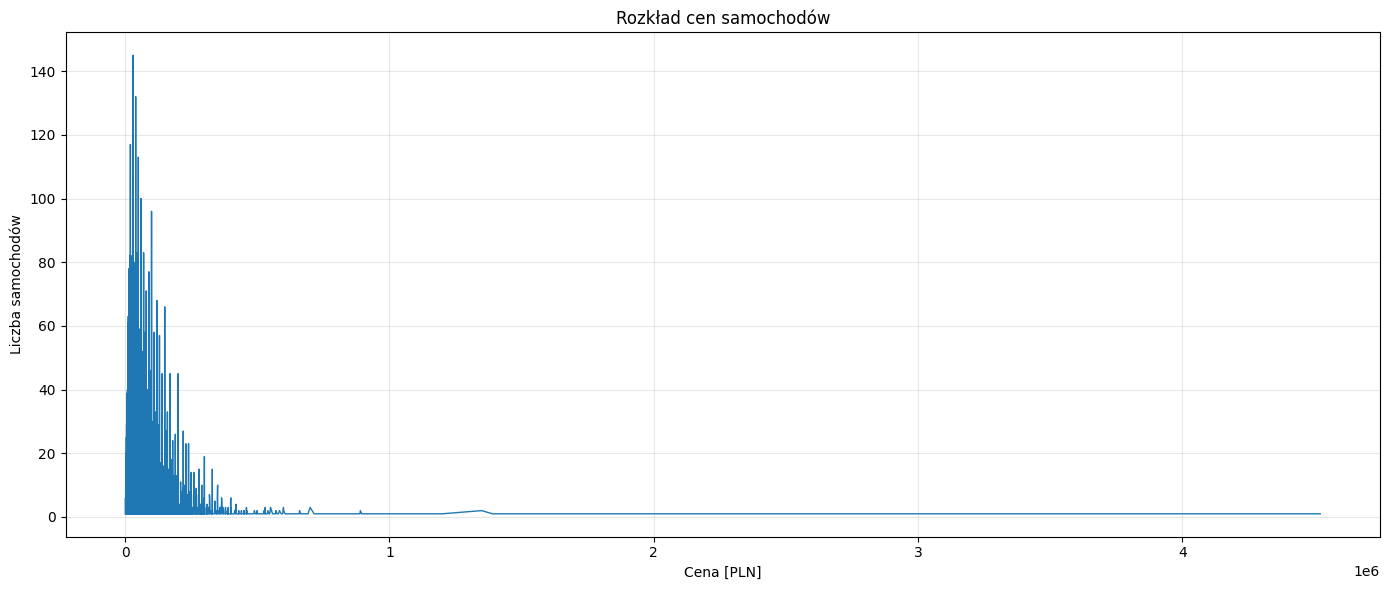

In [95]:
import matplotlib.pyplot as plt

price_counts = df["Cena"].value_counts().sort_index()

plt.figure(figsize=(14, 6))
plt.plot(price_counts.index, price_counts.values, linewidth=1)
plt.xlabel("Cena [PLN]")
plt.ylabel("Liczba samochodów")
plt.title("Rozkład cen samochodów")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Zatem zastosowane zostanie usuwanie logiczne, domenowe.

In [96]:
start_len = len(df)

df = df[(df['Cena'] >= 2500) & (df['Cena'] <= 800000)]

df = df[(df['Przebieg'] < 700000)]

warunek_pojemnosci = (df['Pojemność skokowa'] == 0) | ((df['Pojemność skokowa'] >= 600) & (df['Pojemność skokowa'] <= 8500))
df = df[warunek_pojemnosci]

df = df[df['Rok produkcji'] >= 1990]

print(f"Baza przed filtrowaniem: {start_len}")
print(f"Baza po filtrowaniu: {len(df)}")
print(f"Usunięto {start_len - len(df)} ekstremalnych przypadków (outlierów).")

Baza przed filtrowaniem: 14355
Baza po filtrowaniu: 14180
Usunięto 175 ekstremalnych przypadków (outlierów).


Feature engineering - zamiana rocznika na wiek samochodu

In [97]:
import datetime
df['Wiek'] = datetime.date.today().year - df['Rok produkcji']
df['Marka'] = df['Tytuł'].str.split(' ').str[0]

df = df.drop(columns=['Rok produkcji', 'Tytuł', 'URL'])

czestotliwosc_marek = df['Marka'].value_counts()
popularne_marki = czestotliwosc_marek[czestotliwosc_marek >= 30].index
df.loc[~df['Marka'].isin(popularne_marki), 'Marka'] = 'Inne'

df

,Cena,Przebieg,Pojemność skokowa,Moc,Rodzaj paliwa,Skrzynia biegów,Wiek,Marka
0,327809,1,0,292,Elektryczny,Automatyczna,1,Mercedes-Benz
1,59000,118760,1969,254,Benzyna,Automatyczna,6,Volvo
2,80000,120000,1998,252,Benzyna,Automatyczna,7,BMW
3,239000,22,0,1020,Elektryczny,Automatyczna,4,Inne
4,74900,5,1499,136,Benzyna,Manualna,0,Inne
...,...,...,...,...,...,...,...,...
15963,99900,1,1198,130,Benzyna,Automatyczna,1,Opel
15964,7999,341000,1995,163,Diesel,Automatyczna,20,BMW
15965,109900,2,1199,145,Hybryda,Automatyczna,1,Peugeot
15966,45500,49000,1200,110,Benzyna,Manualna,6,Citroën


Encoding/One-Hot Encoding - tworzenie dummies, typu czy_elekryk: 0, czy_diesel: 1

In [98]:
df_ml = pd.get_dummies(df, columns=['Rodzaj paliwa', 'Skrzynia biegów', 'Marka'], drop_first=True, dtype=int)

Zapisanie datasetu

In [99]:
df_ml.to_csv("dane_gotowe_ML.csv", index=False)
print(f"Zapisano zbiór")
df_ml

Zapisano zbiór


,Cena,Przebieg,Pojemność skokowa,Moc,Wiek,Rodzaj paliwa_Benzyna+LPG,Rodzaj paliwa_Diesel,Rodzaj paliwa_Elektryczny,Rodzaj paliwa_Hybryda,Rodzaj paliwa_Hybryda Plug-in,...,Marka_Peugeot,Marka_Porsche,Marka_Renault,Marka_Seat,Marka_Skoda,Marka_Subaru,Marka_Suzuki,Marka_Toyota,Marka_Volkswagen,Marka_Volvo
0,327809,1,0,292,1,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
1,59000,118760,1969,254,6,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
2,80000,120000,1998,252,7,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,239000,22,0,1020,4,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
4,74900,5,1499,136,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15963,99900,1,1198,130,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
15964,7999,341000,1995,163,20,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
15965,109900,2,1199,145,1,0,0,0,1,0,...,1,0,0,0,0,0,0,0,0,0
15966,45500,49000,1200,110,6,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
